# Goofy Screener — Phase 6: Portfolio Construction
**Correlation Analysis · Cluster Detection · Adjusted Position Sizing**

---

## The problem Phase 5 left unsolved

Phase 5 sized each asset **independently**. It asked:
> *"Given this strategy's edge and this asset's volatility — how much should I bet?"*

It did **not** ask:
> *"How does this position interact with everything else I'm holding?"*

Imagine holding NVDA, AAPL, and MSFT simultaneously. Phase 5 might say 20% each = 60% deployed.
But those three assets move together — on a bad US-tech day, **all three lose at once**.
You don't have 3 independent bets. You have 1 concentrated bet expressed 3 ways.

## Phase 6 fixes this — three steps:

| Step | What it does |
|---|---|
| **1. Correlation matrix** | Measure how closely every pair of TRADE-signal assets moves together |
| **2. Cluster detection** | Group assets that are strongly correlated (ρ ≥ 0.65) into the same cluster |
| **3. Adjusted sizing** | Scale down positions within clusters so correlated bets don't double up |

**Adjustment formula:** `adj_size = phase5_size × (1 / √cluster_size)`

- Solo asset (no correlations above threshold): keep full Phase 5 size
- Cluster of 2: each scaled to 1/√2 ≈ 71% of Phase 5 size
- Cluster of 4: each scaled to 1/√4 = 50% of Phase 5 size

---
## Part 1 — Correlation intuition: a quick demo

Before running the screener, let's build intuition about what correlation means for a portfolio.

High-corr pair:  ρ = 0.91
  Asset A vol:   16.1%
  Asset B vol:   16.5%
  Portfolio vol: 15.9%  ← barely reduced

Low-corr pair:   ρ = 0.07
  Asset A vol:   15.2%
  Asset B vol:   17.0%
  Portfolio vol: 11.8%  ← genuinely diversified


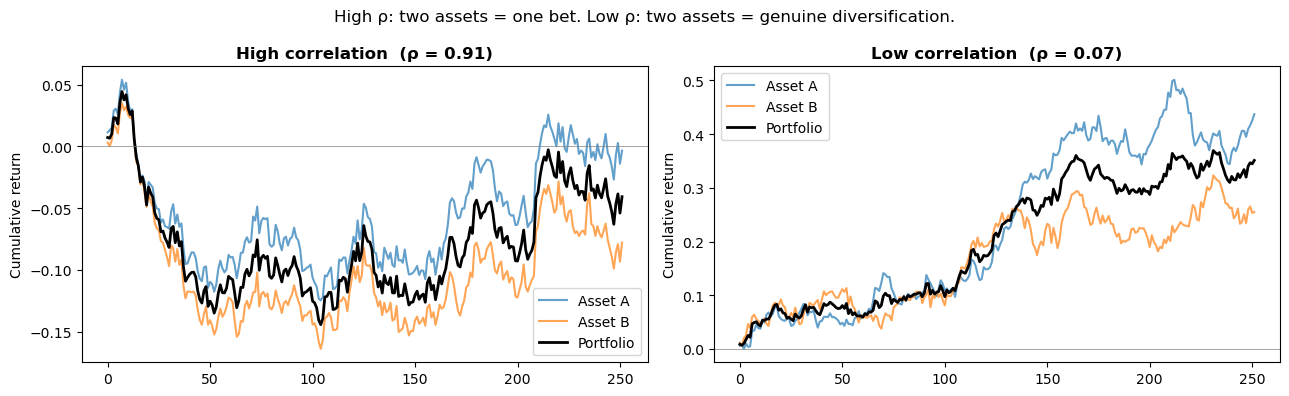


KEY INSIGHT:
  High-corr portfolio vol ≈ single asset vol  → no real diversification
  Low-corr portfolio vol  < single asset vol  → risk genuinely reduced


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Simulate two correlated assets ─────────────────────────────────────────
np.random.seed(42)
n = 252
market = np.random.randn(n) * 0.01   # shared "market" shock

# High correlation scenario: both assets heavily driven by market
asset_A_hi = market + np.random.randn(n) * 0.003
asset_B_hi = market + np.random.randn(n) * 0.003

# Low correlation scenario: each mostly idiosyncratic
asset_A_lo = market * 0.2 + np.random.randn(n) * 0.01
asset_B_lo = market * 0.2 + np.random.randn(n) * 0.01

corr_hi = np.corrcoef(asset_A_hi, asset_B_hi)[0, 1]
corr_lo = np.corrcoef(asset_A_lo, asset_B_lo)[0, 1]

# Equal-weight portfolio of each pair
port_hi = (asset_A_hi + asset_B_hi) / 2
port_lo = (asset_A_lo + asset_B_lo) / 2

print(f"High-corr pair:  ρ = {corr_hi:.2f}")
print(f"  Asset A vol:   {asset_A_hi.std()*np.sqrt(252)*100:.1f}%")
print(f"  Asset B vol:   {asset_B_hi.std()*np.sqrt(252)*100:.1f}%")
print(f"  Portfolio vol: {port_hi.std()*np.sqrt(252)*100:.1f}%  ← barely reduced")
print()
print(f"Low-corr pair:   ρ = {corr_lo:.2f}")
print(f"  Asset A vol:   {asset_A_lo.std()*np.sqrt(252)*100:.1f}%")
print(f"  Asset B vol:   {asset_B_lo.std()*np.sqrt(252)*100:.1f}%")
print(f"  Portfolio vol: {port_lo.std()*np.sqrt(252)*100:.1f}%  ← genuinely diversified")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, A, B, port, corr, label in [
    (axes[0], asset_A_hi, asset_B_hi, port_hi, corr_hi, "High correlation"),
    (axes[1], asset_A_lo, asset_B_lo, port_lo, corr_lo, "Low correlation"),
]:
    ax.plot((1 + pd.Series(A)).cumprod() - 1, label="Asset A", alpha=0.7)
    ax.plot((1 + pd.Series(B)).cumprod() - 1, label="Asset B", alpha=0.7)
    ax.plot((1 + pd.Series(port)).cumprod() - 1,
            label="Portfolio", color="black", lw=2)
    ax.set_title(f"{label}  (ρ = {corr:.2f})", fontweight="bold")
    ax.set_ylabel("Cumulative return")
    ax.legend()
    ax.axhline(0, color="grey", lw=0.5)
plt.suptitle("High ρ: two assets = one bet. Low ρ: two assets = genuine diversification.",
             fontsize=12)
plt.tight_layout()
plt.show()

print()
print("KEY INSIGHT:")
print("  High-corr portfolio vol ≈ single asset vol  → no real diversification")
print("  Low-corr portfolio vol  < single asset vol  → risk genuinely reduced")

---
## Part 2 — The 1/√N adjustment: why it works

If you hold N **perfectly correlated** assets equally:
- Combined vol = single asset vol (no reduction at all)
- You've allocated N× the capital for 1× the independent risk

The fix: scale each position by **1/√N** so the *cluster* as a whole contributes
the same risk as a single independent position would.

| Cluster size | Scale factor | Intuition |
|---|---|---|
| 1 (solo) | 1.00× | No change — unique bet |
| 2 | 0.71× | Each gets 71% of original |
| 3 | 0.58× | Each gets 58% |
| 4 | 0.50× | Each gets 50% — effectively one position split four ways |

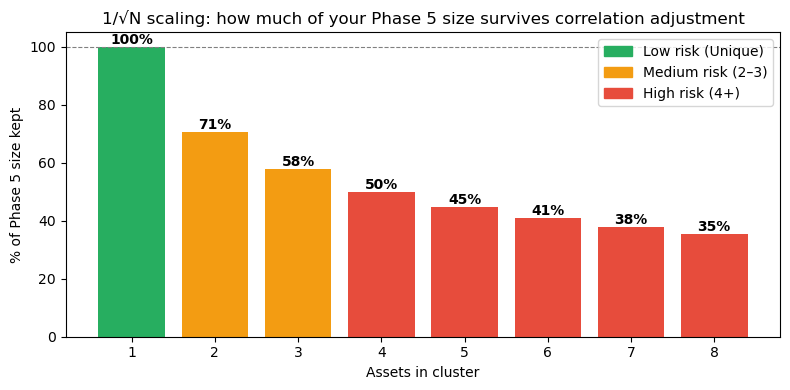

In [2]:
# Visualise the scaling factors
sizes = range(1, 9)
scales = [1 / n**0.5 for n in sizes]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sizes, [s * 100 for s in scales],
              color=['#27AE60' if n == 1 else '#F39C12' if n <= 3 else '#E74C3C'
                     for n in sizes])
ax.axhline(100, color='grey', lw=0.8, linestyle='--', label='Ungated Phase 5 size')
ax.set_xlabel("Assets in cluster")
ax.set_ylabel("% of Phase 5 size kept")
ax.set_title("1/√N scaling: how much of your Phase 5 size survives correlation adjustment")
ax.set_xticks(list(sizes))
for bar, s in zip(bars, scales):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{s*100:.0f}%', ha='center', fontsize=10, fontweight='bold')
green  = mpatches.Patch(color='#27AE60', label='Low risk (Unique)')
orange = mpatches.Patch(color='#F39C12', label='Medium risk (2–3)')
red    = mpatches.Patch(color='#E74C3C', label='High risk (4+)')
ax.legend(handles=[green, orange, red])
plt.tight_layout()
plt.show()

---
## Part 3 — Run Phase 5 screening

Phase 6 builds on top of Phase 5 — same strategy selection, same regime gate, same Kelly sizing.
We run it first, then add the portfolio layer on top.

In [3]:
import sys, os, warnings
warnings.filterwarnings("ignore")
import yfinance as yf
import datetime as dt

# Point to the project directory
PROJECT_DIR = os.path.dirname(os.path.abspath("__file__")) \
              if '__file__' in dir() else os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from goofy_screener_phase5 import (
    screen_market, UNIVERSE_MAP, TRAIN_START, TEST_END, MIN_ROWS
)
from portfolio_builder import (
    compute_correlation_matrix,
    find_clusters,
    adjust_for_correlation,
    portfolio_metrics,
    cluster_label,
    CORR_THRESHOLD,
)

MARKET = "ALL"   # ← change to "US", "ASX", or "JPX" to run one market only

markets_to_run = ["US", "ASX", "JPX"] if MARKET == "ALL" else [MARKET]
today          = dt.datetime.now().strftime("%Y-%m-%d")

print(f"Phase 6 notebook run — {today}")
print(f"Markets: {', '.join(markets_to_run)}")
print(f"Correlation threshold: ρ ≥ {CORR_THRESHOLD}\n")

# Download price data
all_assets = []
for m in markets_to_run:
    all_assets.extend(UNIVERSE_MAP[m])
seen = set(); unique_assets = []
for a in all_assets:
    if a not in seen:
        unique_assets.append(a); seen.add(a)

print(f"Downloading {len(unique_assets)} assets...")
price_data = {}; ohlc_data = {}
for asset in unique_assets:
    try:
        raw = yf.download(asset, start=TRAIN_START, end=TEST_END,
                          auto_adjust=True, progress=False)
        if not raw.empty and len(raw) >= MIN_ROWS:
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            close = raw["Close"].squeeze()
            if isinstance(close, pd.DataFrame): close = close.iloc[:, 0]
            price_data[asset] = close
            if {"High", "Low", "Close"}.issubset(set(raw.columns)):
                ohlc_data[asset] = raw[["High", "Low", "Close"]].copy()
    except: pass

print(f"  → {len(price_data)} assets ready\n")

# Run Phase 5 screening
print("Running Phase 5 screening (strategy + regime + sizing)...")
all_results = {}
for m in markets_to_run:
    print(f"  {m}...")
    all_results[m] = screen_market(m, UNIVERSE_MAP[m], price_data, ohlc_data)

combined = pd.concat([df for df in all_results.values() if not df.empty],
                     ignore_index=True)

print(f"\nPhase 5 complete — {len(combined)} assets screened")
for tier in ["S", "A", "B", "Skip"]:
    print(f"  {tier}: {len(combined[combined['Tier'] == tier])}")
trade_count = len(combined[combined["Today's Verdict"] == "TRADE"])
print(f"  TRADE signals today: {trade_count}")

Phase 6 notebook run — 2026-05-11
Markets: US, ASX, JPX
Correlation threshold: ρ ≥ 0.65



$ALU.AX: possibly delisted; no timezone found

1 Failed download:
['ALU.AX']: possibly delisted; no timezone found
$SKI.AX: possibly delisted; no timezone found

1 Failed download:
['SKI.AX']: possibly delisted; no timezone found


  → 117 assets ready

Running Phase 5 screening (strategy + regime + sizing)...
  US...

  ── Screening US (40 valid assets) ──
    ✅ [A] AAPL           → MACD               | Sharpe:  0.69 | Ret:     84% | DD: -20.9% | DDsaved:   +12.5% | B&H ✗ | Score: 62/100 | 🟢 Bull     → TRADE      | Size: 6%
    🔵 [B] MSFT           → MA Crossover       | Sharpe:  0.37 | Ret:     37% | DD: -21.2% | DDsaved:   +16.0% | B&H ✗ | Score: 45/100 | 🔴 Bear     → STAND DOWN | Size: 7%
    ⬜ [Skip] NVDA           → MA Crossover       | Sharpe:  0.97 | Ret:    404% | DD: -63.6% | DDsaved:    +2.7% | B&H ✗ | Score: 56/100 | 🟢 Bull     → TRADE      | Size: 11%
    🔵 [B] GOOGL          → RSI                | Sharpe:  0.16 | Ret:     22% | DD: -44.3% | DDsaved:    +0.0% | B&H ✗ | Score: 25/100 | 🔴 Bull     → STAND DOWN | Size: 8%
    ⬜ [Skip] META           → RSI                | Sharpe: -0.10 | Ret:    -17% | DD: -71.5% | DDsaved:    +5.3% | B&H ✗ | Score: 9/100 | 🟢 Sideways → TRADE      | Size: 2%
    🔵 [B] A

---
## Part 4 — Build the correlation matrix

We only correlate **TRADE-signal** assets — no point including assets we won't trade.
Correlations are computed on the **test period (2021–present)** daily returns,
not the training period. We want to know how these assets move *now*, not historically.

In [7]:
# Get TRADE-signal, non-Skip assets
trade_assets = combined[
    (combined["Today's Verdict"] == "TRADE") &
    (combined["Tier"] != "Skip")
].copy()

print(f"TRADE-signal assets to correlate: {len(trade_assets)}")
print(trade_assets[["Market", "Asset", "Tier", "Best Strategy"]].to_string(index=False))

# Build returns from test period only
test_start = pd.Timestamp("2021-01-01")
returns_dict = {}
for asset in trade_assets["Asset"]:
    if asset in price_data:
        prices = price_data[asset]
        test_prices = prices[prices.index >= test_start]
        if len(test_prices) >= 60:
            returns_dict[asset] = test_prices.pct_change().dropna()

print(f"\nAssets with sufficient test-period data: {len(returns_dict)}")

# Correlation matrix
corr_matrix = compute_correlation_matrix(returns_dict)
print(f"\nCorrelation matrix shape: {corr_matrix.shape}")
print("\nFirst 6×6 (if available):")
print(corr_matrix.iloc[:6, :6].round(2).to_string())

TRADE-signal assets to correlate: 36
Market  Asset Tier   Best Strategy
    US   AAPL    A            MACD
    US   AMZN    B    MA Crossover
    US   TSLA    B            MACD
    US    BAC    B            MACD
    US     MS    B    MA Crossover
    US   ABBV    A             RSI
    US    XOM    A            MACD
    US    CVX    A            MACD
    US     PG    S Bollinger Bands
    US    PEP    B            MACD
    US    CAT    A            MACD
    US    RTX    B            MACD
    US    SPY    A            MACD
    US    QQQ    A            MACD
    US    IWM    B            MACD
   ASX CBA.AX    S             RSI
   ASX ANZ.AX    A            MACD
   ASX FMG.AX    B    MA Crossover
   ASX WDS.AX    B            MACD
   ASX STW.AX    S             RSI
   JPX 7267.T    B             RSI
   JPX 6758.T    B Bollinger Bands
   JPX 6501.T    A    MA Crossover
   JPX 6723.T    B    MA Crossover
   JPX 9432.T    A             RSI
   JPX 9433.T    S Bollinger Bands
   JPX 9434.T    A

---
## Part 5 — Visualise the correlation heatmap

The heatmap is the most intuitive way to see your portfolio's risk structure:
- **Dark red** = high correlation → same cluster, same risk
- **White** = near-zero correlation → independent bets
- **Blue** = negative correlation → natural hedge (rare in equities)

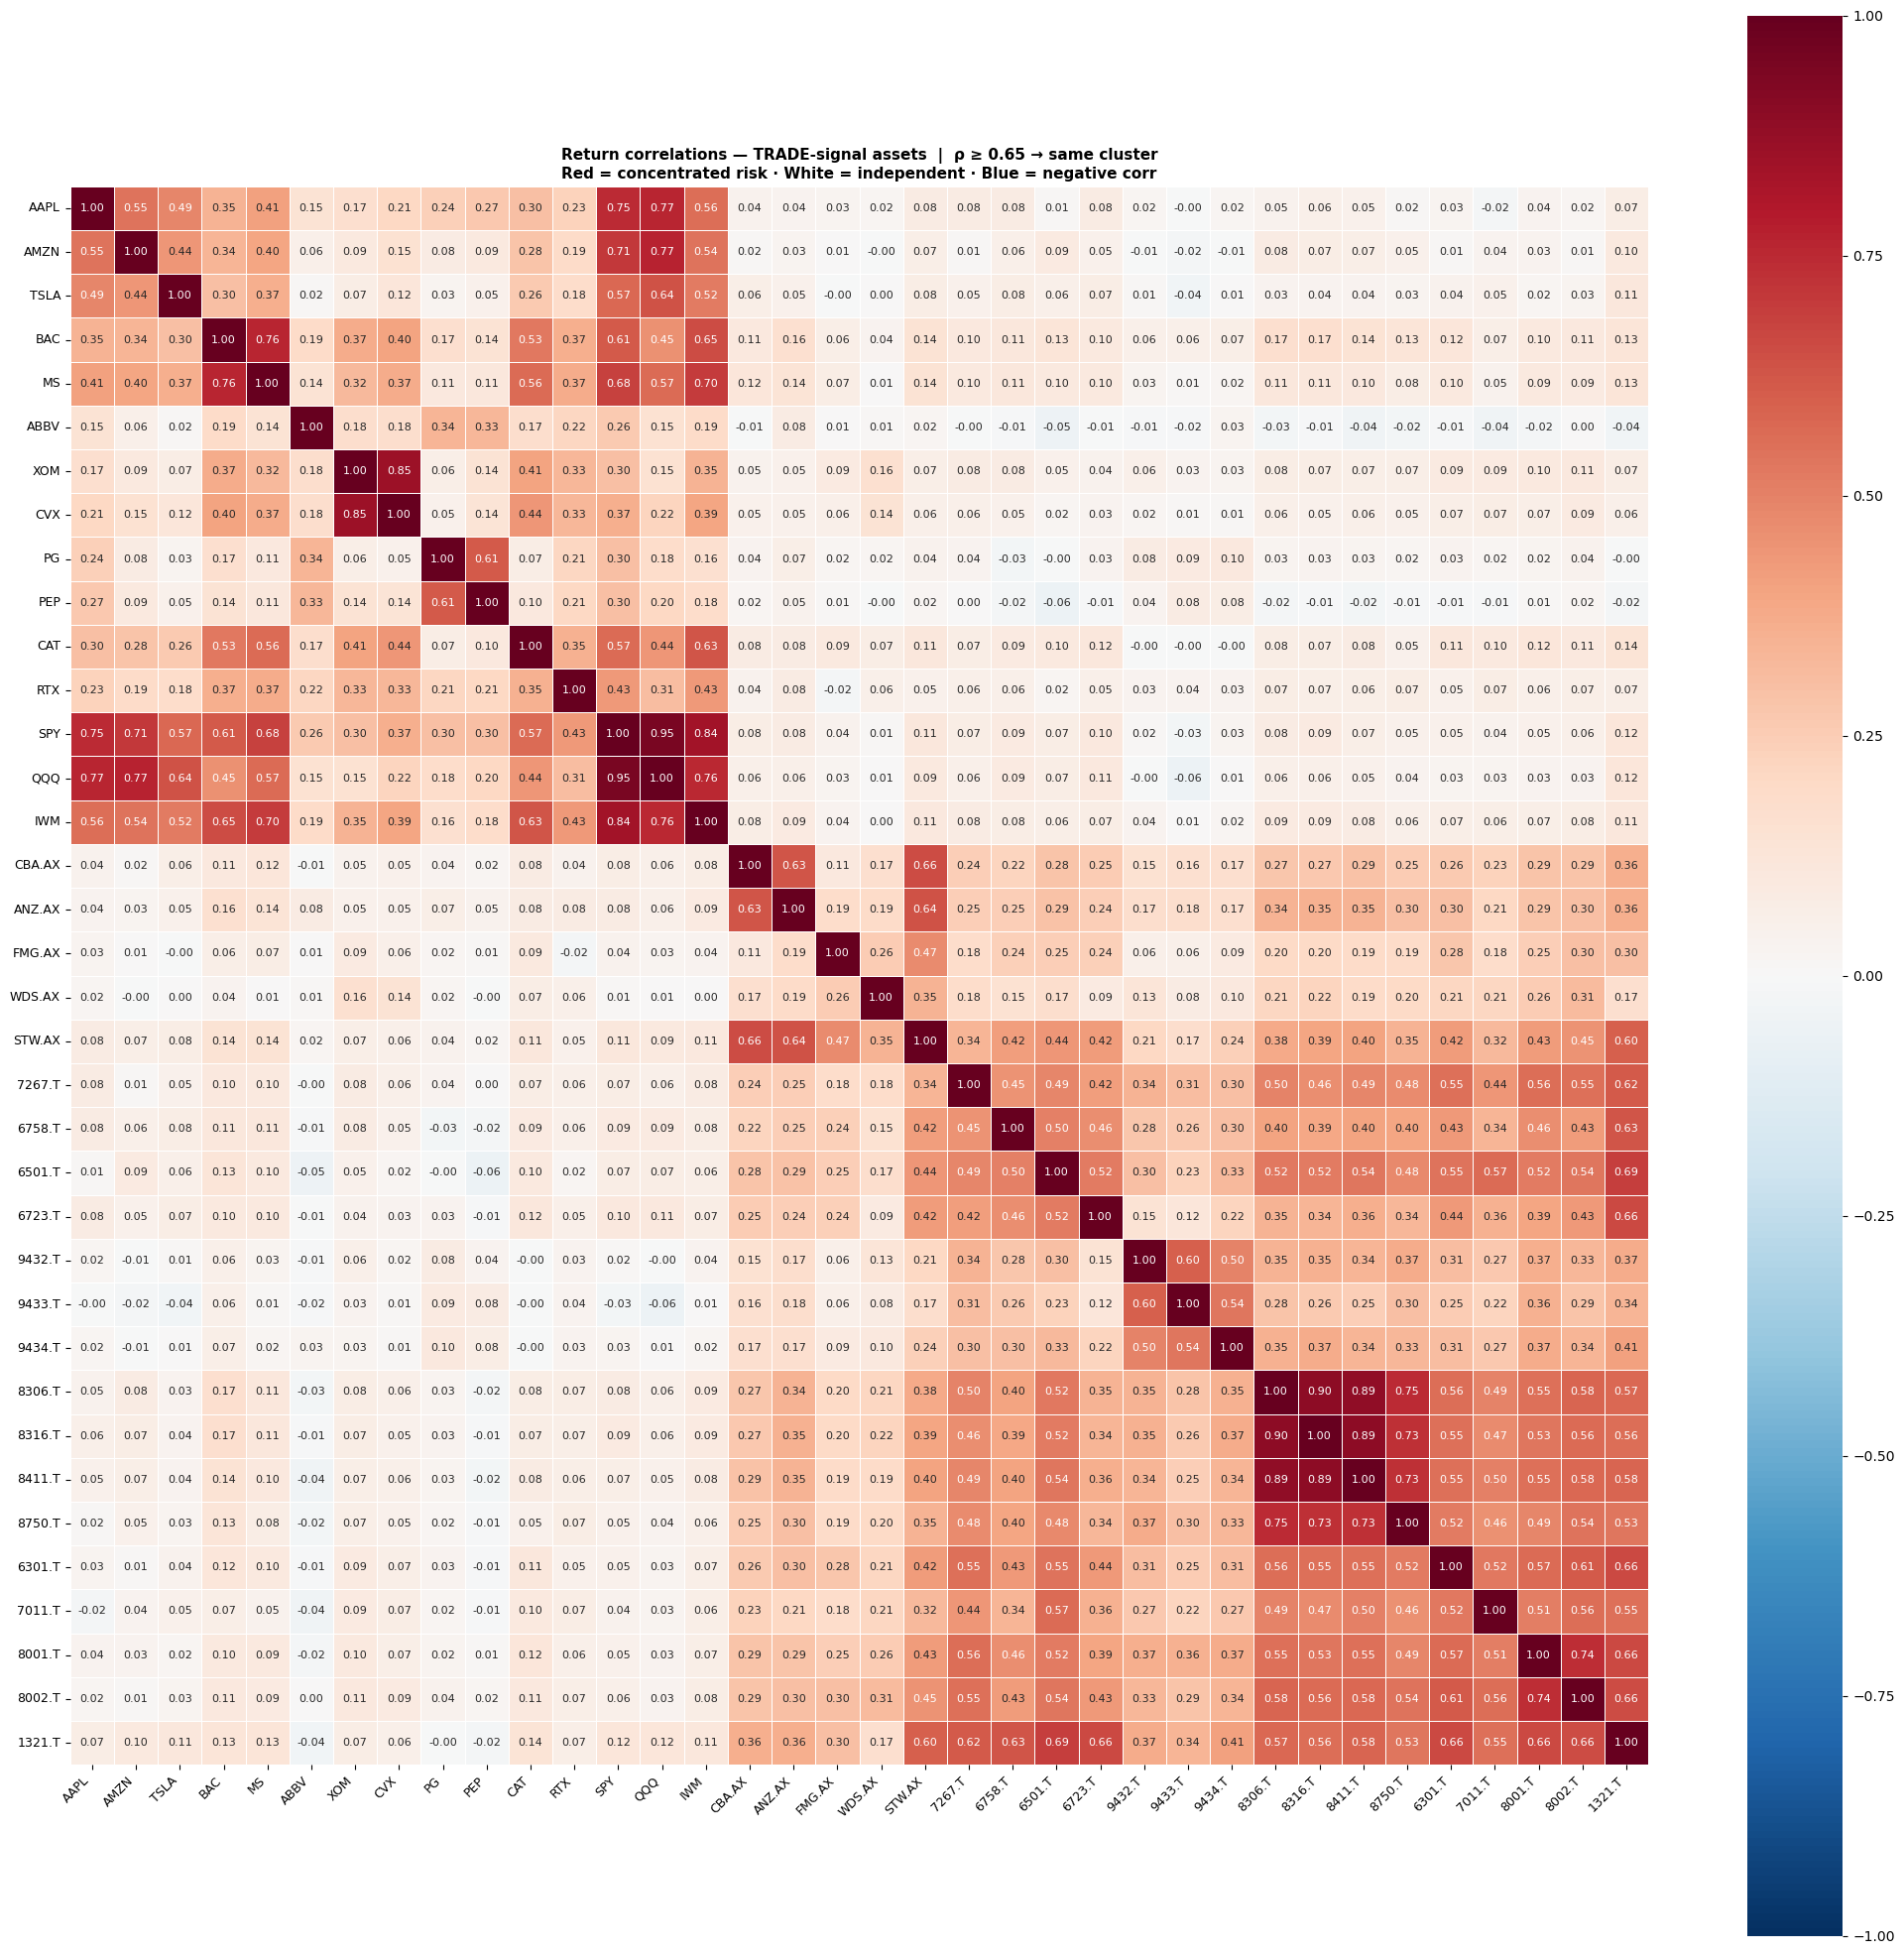


Pairs with ρ ≥ 0.65 (will share a cluster):
  AAPL           ↔ SPY             ρ = 0.75
  AAPL           ↔ QQQ             ρ = 0.77
  AMZN           ↔ SPY             ρ = 0.71
  AMZN           ↔ QQQ             ρ = 0.77
  BAC            ↔ MS              ρ = 0.76
  BAC            ↔ IWM             ρ = 0.65
  MS             ↔ SPY             ρ = 0.68
  MS             ↔ IWM             ρ = 0.70
  XOM            ↔ CVX             ρ = 0.85
  SPY            ↔ QQQ             ρ = 0.95
  SPY            ↔ IWM             ρ = 0.84
  QQQ            ↔ IWM             ρ = 0.76
  CBA.AX         ↔ STW.AX          ρ = 0.66
  6501.T         ↔ 1321.T          ρ = 0.69
  6723.T         ↔ 1321.T          ρ = 0.66
  8306.T         ↔ 8316.T          ρ = 0.90
  8306.T         ↔ 8411.T          ρ = 0.89
  8306.T         ↔ 8750.T          ρ = 0.75
  8316.T         ↔ 8411.T          ρ = 0.89
  8316.T         ↔ 8750.T          ρ = 0.73
  8411.T         ↔ 8750.T          ρ = 0.73
  6301.T         ↔ 1321.T      

In [6]:
import seaborn as sns

if corr_matrix.empty or len(corr_matrix) < 2:
    print("Not enough TRADE-signal assets to draw heatmap.")
else:
    fig_h = max(6, len(corr_matrix) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_h + 1, fig_h))

    mask = corr_matrix.isna()
    sns.heatmap(
        corr_matrix,
        annot=True, fmt=".2f", linewidths=0.5,
        cmap="RdBu_r",        # red = high corr, blue = negative
        vmin=-1, vmax=1,
        center=0,
        mask=mask,
        square=True, ax=ax,
        annot_kws={"size": 8},
    )
    ax.set_title(
        f"Return correlations — TRADE-signal assets  |  "
        f"ρ ≥ {CORR_THRESHOLD} → same cluster\n"
        f"Red = concentrated risk · White = independent · Blue = negative corr",
        fontsize=11, fontweight="bold"
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Highlight pairs above threshold
    print(f"\nPairs with ρ ≥ {CORR_THRESHOLD} (will share a cluster):")
    found = False
    tickers = list(corr_matrix.columns)
    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            val = corr_matrix.iloc[i, j]
            if pd.notna(val) and val >= CORR_THRESHOLD:
                print(f"  {tickers[i]:14} ↔ {tickers[j]:14}  ρ = {val:.2f}")
                found = True
    if not found:
        print(f"  None — all TRADE assets are below ρ = {CORR_THRESHOLD}. ")
        print("  Great news: every position is a genuinely independent bet.")

---
## Part 6 — Cluster detection

We use **connected components**: two assets are in the same cluster if their correlation
is above the threshold. This is transitive — if A↔B and B↔C, all three cluster together
even if A-C is below threshold, because B acts as a bridge.

Think of it like a social network: if you know someone who knows someone, you're in the same circle.

In [ ]:
cluster_map = find_clusters(corr_matrix, CORR_THRESHOLD)

# Count cluster sizes among TRADE assets only
from collections import Counter
active_assets = list(trade_assets["Asset"])
cid_counts    = Counter(cluster_map.get(a) for a in active_assets if a in cluster_map)

cluster_sizes_all = {a: cid_counts.get(cluster_map.get(a), 1) for a in active_assets}

print(f"Cluster results (threshold ρ ≥ {CORR_THRESHOLD}):")
print(f"{'Asset':16} {'Cluster':10} {'Size':6} {'Corr Risk'}")
print("-" * 50)
for asset in sorted(active_assets):
    cid  = cluster_map.get(asset)
    n    = cluster_sizes_all.get(asset, 1)
    lbl  = cluster_label(asset, cluster_map, cluster_sizes_all)
    risk = "High" if n >= 4 else "Medium" if n >= 2 else "Low"
    print(f"  {asset:14} {lbl:10} {n:6} {risk}")

# Group by cluster for easy reading
print("\nCluster membership:")
clusters_grouped = {}
for asset in active_assets:
    lbl = cluster_label(asset, cluster_map, cluster_sizes_all)
    clusters_grouped.setdefault(lbl, []).append(asset)
for lbl, members in sorted(clusters_grouped.items()):
    if lbl == "Unique":
        risk_label = "Low — each is an independent bet"
    else:
        n = len(members)
        risk_label = "High" if n >= 4 else "Medium" if n >= 2 else "Low"
    print(f"  {lbl:12} ({risk_label}): {', '.join(members)}")

---
## Part 7 — Correlation-adjusted position sizes

Now we apply the 1/√N adjustment to Phase 5 sizes.

After adjustment, if total allocation exceeds 100%, everything is scaled down proportionally
so the portfolio stays fully-but-not-over-invested.

In [9]:
# Collect Phase 5 recommended sizes
raw_sizes = {}
for _, row in trade_assets.iterrows():
    raw_sizes[row["Asset"]] = row.get("Recommended Size %") or 0.0

# Adjust
adj_sizes, cluster_sizes_map, corr_risk = adjust_for_correlation(
    active_assets, raw_sizes, cluster_map
)

# Display comparison table
print(f"{'Asset':16} {'Cluster':10} {'Phase5 Size':12} {'Adj Size':10} {'Change':8} {'Corr Risk'}")
print("-" * 70)

rows_display = []
for asset in sorted(active_assets, key=lambda a: -(adj_sizes.get(a) or 0)):
    p5  = raw_sizes.get(asset, 0) or 0
    adj = adj_sizes.get(asset, 0) or 0
    chg = adj - p5
    lbl = cluster_label(asset, cluster_map, cluster_sizes_map)
    risk = corr_risk.get(asset, "—")
    sign = "+" if chg >= 0 else ""
    print(f"  {asset:14} {lbl:10} {p5:>9.1f}%  {adj:>7.1f}%  {sign}{chg:>5.1f}%  {risk}")
    rows_display.append({"Asset": asset, "Phase5 %": p5, "Adj %": adj, "Cluster": lbl})

total_p5  = sum(raw_sizes.values())
total_adj = sum(adj_sizes.values())
print(f"\n  TOTAL Phase 5:   {total_p5:.1f}%")
print(f"  TOTAL Adjusted:  {total_adj:.1f}%")
print(f"  Capital freed up: {total_p5 - total_adj:.1f}% (held as cash / reserve)")

Asset            Cluster    Phase5 Size  Adj Size   Change   Corr Risk
----------------------------------------------------------------------
  9432.T         Unique          31.5%     11.5%  -20.0%  Low
  9434.T         Unique          30.1%     11.0%  -19.1%  Low
  7267.T         Unique          27.5%     10.0%  -17.5%  Low
  STW.AX         C9              38.0%      9.8%  -28.2%  Medium
  CBA.AX         C9              26.3%      6.8%  -19.5%  Medium
  ABBV           Unique          16.5%      6.0%  -10.5%  Low
  PG             Unique          14.3%      5.2%   -9.1%  Low
  9433.T         Unique          14.3%      5.2%   -9.1%  Low
  FMG.AX         Unique           8.3%      3.0%   -5.3%  Low
  TSLA           Unique           6.9%      2.5%   -4.4%  Low
  SPY            C1              17.4%      2.4%  -15.0%  High
  6758.T         Unique           6.6%      2.4%   -4.2%  Low
  7011.T         Unique           5.1%      1.9%   -3.2%  Low
  PEP            Unique           5.0%      1

---
## Part 8 — Portfolio-level metrics

Two metrics that tell you the *quality* of your portfolio's diversification:

**Portfolio Vol (annualised):** the actual expected volatility of the whole portfolio.
Lower than any individual asset means diversification is working.

**Diversification Ratio:** weighted average individual vol ÷ portfolio vol.
- = 1.0 → everything moves together (no diversification benefit)
- > 1.0 → genuine diversification; higher is better
- A ratio of 1.5 means the portfolio vol is 33% lower than a single-asset equivalent

**Effective N:** Diversification Ratio² — roughly how many truly *independent* bets you have.

In [10]:
# Portfolio weights = adjusted sizes as fractions (0–1)
weights = {a: v / 100.0 for a, v in adj_sizes.items() if v and v > 0}

port_m = portfolio_metrics(returns_dict, weights)

print("PORTFOLIO METRICS (adjusted weights)")
print("=" * 42)
if port_m.get("port_vol_ann"):
    print(f"  Portfolio vol (ann.):         {port_m['port_vol_ann']}%")
    print(f"  Diversification Ratio:        {port_m['div_ratio']}")
    print(f"  Effective independent bets:   {port_m['effective_n']}")
    print(f"  Positions included:           {port_m['n_positions']}")

    dr = port_m['div_ratio']
    print()
    if dr >= 1.5:
        print("  ✅ Strong diversification — portfolio vol materially below individual assets")
    elif dr >= 1.2:
        print("  🔵 Moderate diversification — some benefit from mixing markets/strategies")
    elif dr >= 1.05:
        print("  🟡 Weak diversification — assets are fairly correlated overall")
    else:
        print("  🔴 Near-zero diversification — portfolio behaves like one concentrated bet")
else:
    print("  Not enough data to compute portfolio metrics.")

# Also compare Phase 5 vs Phase 6 total allocation
print()
print(f"  Total Phase 5 allocation:  {total_p5:.1f}%")
print(f"  Total Phase 6 allocation:  {total_adj:.1f}%")

PORTFOLIO METRICS (adjusted weights)
  Portfolio vol (ann.):         11.3%
  Diversification Ratio:        2.06
  Effective independent bets:   4.2
  Positions included:           36

  ✅ Strong diversification — portfolio vol materially below individual assets

  Total Phase 5 allocation:  354.7%
  Total Phase 6 allocation:  99.9%


---
## Part 9 — Visualise final portfolio allocation

In [ ]:
df_viz = pd.DataFrame([
    {
        "Asset":     a,
        "Phase5 %":  raw_sizes.get(a, 0),
        "Adj %":     adj_sizes.get(a, 0),
        "Cluster":   cluster_label(a, cluster_map, cluster_sizes_map),
        "Corr Risk": corr_risk.get(a, "Low"),
    }
    for a in active_assets
]).sort_values("Adj %", ascending=True).reset_index(drop=True)

if df_viz.empty:
    print("No TRADE-signal assets to plot.")
else:
    risk_colors = {"Low": "#27AE60", "Medium": "#F39C12", "High": "#E74C3C"}
    bar_colors  = [risk_colors.get(r, "grey") for r in df_viz["Corr Risk"]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, len(df_viz) * 0.45)))

    ax1.barh(df_viz["Asset"], df_viz["Phase5 %"], color=bar_colors, alpha=0.75)
    ax1.set_xlabel("Position size (%)"); ax1.set_title("Phase 5 — Raw sizing")
    ax1.axvline(0, color='grey', lw=0.5)

    ax2.barh(df_viz["Asset"], df_viz["Adj %"], color=bar_colors)
    ax2.set_xlabel("Position size (%)"); ax2.set_title("Phase 6 — Correlation-adjusted")
    ax2.axvline(0, color='grey', lw=0.5)

    # Cluster labels — use asset name as Y coordinate (matches string-category axis)
    for ax, col in [(ax1, "Phase5 %"), (ax2, "Adj %")]:
        for _, row in df_viz.iterrows():
            v = row[col]
            if v > 0:
                ax.text(v + 0.3, row["Asset"], row["Cluster"],
                        va='center', fontsize=8, color='#333')

    green  = mpatches.Patch(color='#27AE60', label='Low Corr Risk (Unique)')
    orange = mpatches.Patch(color='#F39C12', label='Medium (2–3 in cluster)')
    red    = mpatches.Patch(color='#E74C3C', label='High (4+ in cluster)')
    ax2.legend(handles=[green, orange, red], loc='lower right', fontsize=8)

    plt.suptitle("Phase 5 → Phase 6: correlation adjustment reduces clustered positions",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## Part 10 — Save Phase 6 Excel report

Runs the full Phase 6 screener and saves to `screener_output/Goofy_Phase6_YYYY-MM-DD.xlsx`.

**New tabs:**
- `🔗 Correlation Matrix` — heatmap-style pairwise correlations
- `📊 Portfolio View` — final adjusted weights + portfolio metrics

In [12]:
from goofy_screener_phase6 import (
    run_portfolio_construction,
    attach_phase6_columns,
    write_excel_phase6,
)

# Build Phase 6 output
p6 = run_portfolio_construction(combined, price_data)

# Attach new columns to all market dataframes
all_results_p6 = attach_phase6_columns(
    {m: df.copy() for m, df in all_results.items()}, p6
)

# Save Excel
xlsx_path = write_excel_phase6(all_results_p6, today, p6)
print(f"\nSaved → {xlsx_path}")

# Final summary
pm = p6.get("port_metrics", {})
print("\n" + "═" * 60)
print("PHASE 6 COMPLETE")
print("═" * 60)
print(f"  Assets screened:           {len(combined)}")
for tier in ["S", "A", "B", "Skip"]:
    print(f"  {tier} tier:                   {len(combined[combined['Tier'] == tier])}")
print(f"  TRADE signals:             {len(combined[combined["Today's Verdict"] == 'TRADE'])}")
if pm.get("port_vol_ann"):
    print(f"  Portfolio vol (ann.):      {pm['port_vol_ann']}%")
    print(f"  Diversification Ratio:     {pm['div_ratio']}")
    print(f"  Effective independent bets:{pm['effective_n']}")
adj_total = sum(p6.get('adj_sizes', {}).values())
print(f"  Total adj. allocation:     {adj_total:.1f}%")
print("═" * 60)

import subprocess
try:
    subprocess.Popen(["open", xlsx_path])
    print("\nExcel opened.")
except: pass


Saved → /Users/hiro/quant-research/Claude project (me learning)/Quant python learning 1/screener_output/Goofy_Phase6_2026-05-11.xlsx

════════════════════════════════════════════════════════════
PHASE 6 COMPLETE
════════════════════════════════════════════════════════════
  Assets screened:           117
  S tier:                   9
  A tier:                   35
  B tier:                   33
  Skip tier:                   40
  TRADE signals:             45
  Portfolio vol (ann.):      11.3%
  Diversification Ratio:     2.06
  Effective independent bets:4.2
  Total adj. allocation:     99.9%
════════════════════════════════════════════════════════════

Excel opened.
